In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib

In [ ]:
df = pd.read_csv("data.csv")
print("First rows of the dataset:")
display(df.head())

First rows of the dataset:


,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


The feature matrix X contains all sensor readings and derived variables.
The target vector y is the column we want to predict: "fail" (1) or "no fail" (0).

In [ ]:
X = df.drop(columns=["fail"])  # Features
y = df["fail"]                 # Target

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)
print("Target variable distribution:")
print(y.value_counts())

Shape of X (features): (944, 9)
Shape of y (target): (944,)
Target variable distribution:
fail
0    551
1    393
Name: count, dtype: int64


split the data into training and test sets.
- test_size=0.2 reserves 20% for testing
- stratify=y ensures the class distribution is maintained
- random_state=42 makes results reproducible

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

SMOTE creates synthetic examples of the minority class to balance the dataset.

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribution before SMOTE:\n", y_train.value_counts())
print("Distribution after SMOTE:\n", y_train_res.value_counts())

Distribution before SMOTE:
 fail
0    441
1    314
Name: count, dtype: int64
Distribution after SMOTE:
 fail
0    441
1    441
Name: count, dtype: int64


#### Create and Train XGBoost Model
XGBoost is highly effective for tabular data.
Parameters:
- n_estimators: number of trees
- max_depth: depth of each tree
- learning_rate: step size for updating weights
- n_jobs=-1 uses all CPU cores
- random_state ensures reproducibility

In [ ]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

# Train the model using the balanced training data
model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-1, num_parallel_tree=None, ...)

Predict class labels and probabilities for the test set

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

#### Evaluate Model Performance
Classification report provides precision, recall, f1-score.

Confusion matrix shows correct vs incorrect predictions.

ROC-AUC measures model's ability to separate classes.

PR-AUC is useful when classes are imbalanced.

Cross-validation F1 shows stability across folds.

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

f1_scores = cross_val_score(model, X_train_res, y_train_res, cv=5, scoring="f1")
print(f"F1 average (cross-validation): {f1_scores.mean():.3f}")

Classification Report:
              precision    recall  f1-score   support

           0      0.933     0.891     0.912       110
           1      0.857     0.911     0.883        79

    accuracy                          0.899       189
   macro avg      0.895     0.901     0.898       189
weighted avg      0.901     0.899     0.900       189

Confusion Matrix:
[[98 12]
 [ 7 72]]
ROC-AUC: 0.969
PR-AUC: 0.959
F1 average (cross-validation): 0.906


ROC curve:

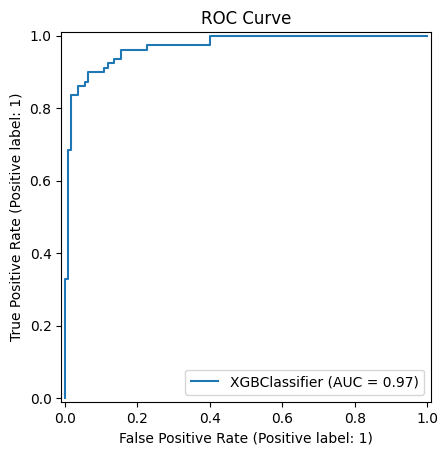

In [ ]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

Precision-Recall curve is more informative when classes are imbalanced

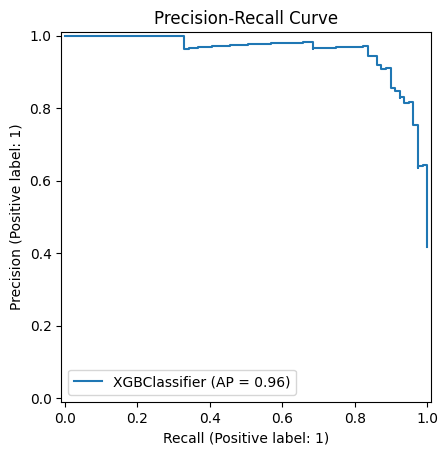

In [ ]:
PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
plt.title("Precision-Recall Curve")
plt.show()

### Feature Importance
Bar chart showing which sensors/features contribute most to predictions

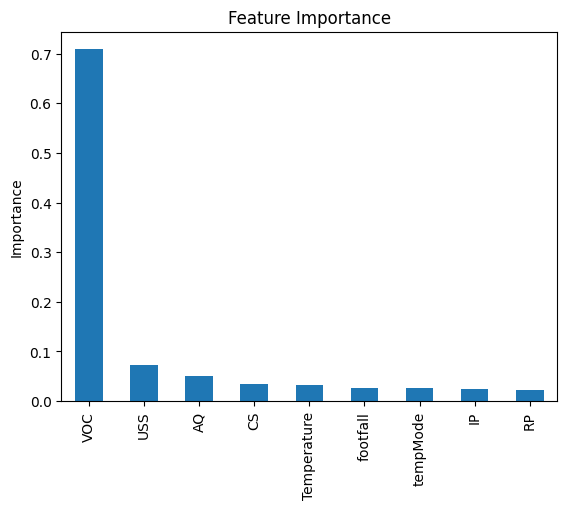

In [ ]:
plt.figure()
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.sort_values(ascending=False).plot(kind="bar")
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

https://www.kaggle.com/code/dayronrodrguez/predictive-maintenance/notebook